In [1]:
import pandas as pd
df = pd.read_csv("/Users/khalifabaobaid/Downloads/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
from sklearn.model_selection import train_test_split
X = df.drop("price", axis=1)
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(436, 12) (109, 12) (436,) (109,)


In [59]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [60]:
df.isna().cumsum().tail(1)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
544,0,0,0,0,0,0,0,0,0,0,0,0,0


In [61]:
for index in range(len(df)): # [0, 1, 2...len(df)]
    if  df.loc[index, "mainroad"]== "yes":
        df.loc[index, "mainroad"] =1
    else:
        df.loc[index, "mainroad"] =0
    
df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,1,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,1,no,yes,no,no,2,yes,semi-furnished


In [91]:
def func(df, columnname):
    for index in range(len(df)):
        if df.loc[index, columnname]=="yes":
            df.loc[index, columnname]=1
        elif df.loc[index, columnname]=="no":
            df.loc[index,columnname]= 0
        else:
            print(df.loc[index, columnname])
            break
    return df



In [92]:
columns = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning",  "prefarea"]
for column in columns:
    print(column)
    df = func(df, column)
print(df.head(3))

mainroad
guestroom
basement
hotwaterheating
airconditioning
prefarea
      price      area  bedrooms  bathrooms  stories mainroad guestroom  \
0  13300000  1.046726         4          2        3        1         0   
1  12250000  1.757010         4          4        4        1         0   
2  12250000  2.218232         3          2        2        1         0   

  basement hotwaterheating airconditioning  parking prefarea furnishingstatus  
0        0               0               1        2        1        furnished  
1        0               0               1        3        0        furnished  
2        1               0               0        2        1   semi-furnished  


In [64]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [93]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['furnishingstatus'] = le.fit_transform(df['furnishingstatus'])
df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,1.046726,4,2,3,1,0,0,0,1,2,1,0
1,12250000,1.757010,4,4,4,1,0,0,0,1,3,0,0
2,12250000,2.218232,3,2,2,1,0,1,0,0,2,1,1


[1,6,4,5,2] # RANGE 1-6
# METHOD 1
MIN MAX SCALING
X_NEW = (X_OLD-MIN(X_ALL))/((MAX(X_ALL))-MIN(x_all))
MIN=1
MAX=6
MAX-MIN=5
x_new = (x_old-1)/5
[0,1,0.6,0.8,0.2] # range 0-1
from sklearn.preprocessing import MinMaxScaler


[1,20,60,40,50] # RANGE 1-60
MIN MAX SCALING 
X_NEW = (X_OLD-MIN(X_ALL))/((MAX(X_ALL))-MIN(x_all))
MIN=1
MAX=60
MAX-MIN=59
x_new = (x_old-1)/59
{0,19/59,1,39/59,49/59} }


# standard SCALER 

In [66]:
df['area']

0      7420
1      8960
2      9960
3      7500
4      7420
       ... 
540    3000
541    2400
542    3620
543    2910
544    3850
Name: area, Length: 545, dtype: int64

In [ ]:
# NORMALIZATION
from sklearn.preprocessing import StandardScaler
import numpy as np
scaler = MinMaxScaler()

df['area'] = scaler.fit_transform(df[['area']])
df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,0.396564,4,2,3,1,0,0,0,1,2,1,0
1,12250000,0.502405,4,4,4,1,0,0,0,1,3,0,0
2,12250000,0.571134,3,2,2,1,0,1,0,0,2,1,1


In [90]:
# NORMALIZATION
from sklearn.preprocessing import StandardScaler
import numpy as np
scaler = StandardScaler()

df['area'] = scaler.fit_transform(df[['area']])
df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,1.046726,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,1.757010,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,2.218232,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


In [68]:
bins = len(df['bedrooms'].unique())

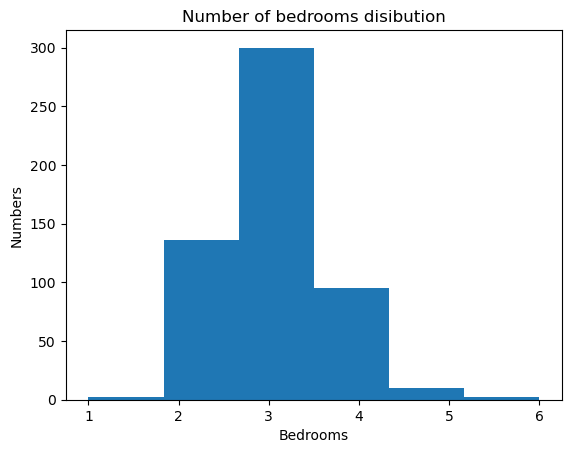

In [69]:
import matplotlib.pyplot as plt

plt.hist(x=df[['bedrooms']], bins=bins)
plt.xlabel("Bedrooms")
plt.title("Number of bedrooms disibution")
plt.ylabel("Numbers")
plt.show()

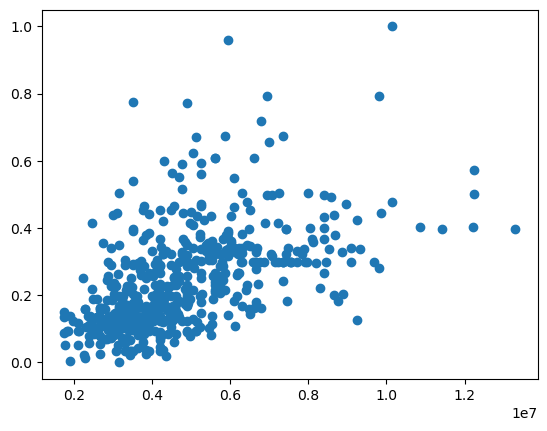

In [70]:
plt.scatter(df[['price']], df[['area']])
plt.show()

In [71]:
nums = [2, 4, 5, 8, 23, 4, 5, 65, 43]

count = 0
for n in nums:
    if (n % 3 == 0 or n % 5 == 0) and not (n % 3 == 0 and n % 5 == 0):
        count += 1

print(count)



3


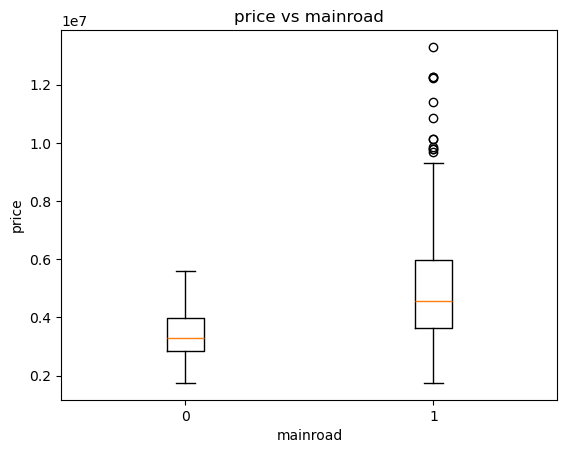

In [88]:
x=[]
for i in range(len(df)):
    if df.loc[i, 'mainroad']==1:
        x.append(df.loc[i, 'price'])

y=[]
for i in range(len(df)):
    if df.loc[i, 'mainroad']==0:
        y.append(df.loc[i, 'price'])
x=[y, x]
plt.boxplot(x, )
plt.xlabel("mainroad")
plt.xticks(ticks = [1,2], labels=[0,1])
plt.ylabel("price")
plt.title("price vs mainroad")
plt.show()


In [95]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,1.046726,4,2,3,1,0,0,0,1,2,1,0
1,12250000,1.757010,4,4,4,1,0,0,0,1,3,0,0
2,12250000,2.218232,3,2,2,1,0,1,0,0,2,1,1
3,12215000,1.083624,4,2,2,1,0,1,0,1,3,1,0
4,11410000,1.046726,4,1,2,1,1,1,0,1,2,0,0


In [106]:
x = df.corr()[['price']]
x

,price
price,1.000000
area,0.535997
bedrooms,0.366494
bathrooms,0.517545
stories,0.420712
mainroad,0.296898
guestroom,0.255517
basement,0.187057
hotwaterheating,0.093073
airconditioning,0.452954


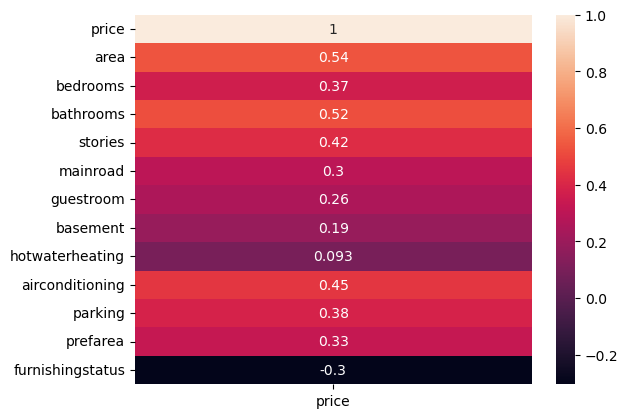

In [108]:
import seaborn as sns
sns.heatmap(x, annot=True)
plt.show()

In [98]:
example = np.random.randint(1, 10, (4,4))
example

array([[6, 5, 4, 4],
       [8, 7, 9, 8],
       [2, 6, 2, 9],
       [9, 8, 6, 4]])

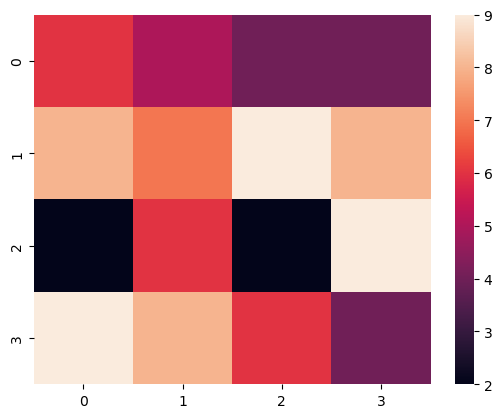

In [99]:
sns.heatmap(example)
plt.show()